# Análisis exploratorio

Partimos de `DF_TODAS_UNION.csv`, generado por `Limpieza_union.ipynb`: la unión ya deduplicada de las 10 fuentes, con las variables derivadas (año, mes, estación, `total_finishers`, `es_finde`), el cruce con la población del INE (`total_poblacion`, `poblacion_h`, `poblacion_d`) y el índice `es_carrera_popular` ya calculados. Toda la limpieza/unión vive en el otro notebook; aquí solo se analiza esta tabla.

In [1]:
from pathlib import Path
import re
import unicodedata

import pandas as pd

RUTA = Path("../../data/processed/union/DF_TODAS_UNION.csv")
todas = pd.read_csv(RUTA, encoding="utf-8-sig")
todas["fecha"] = pd.to_datetime(todas["fecha"])

print("Filas x columnas:", todas.shape)
todas.head()

Filas x columnas: (41544, 24)


,fuente,nombre_carrera,fecha,dia_semana,distancia,tipo_modalidad,publico,finisher_d,finisher_h,municipio,...,estacion,total_finishers,es_finde,municipio_norm,provincia_norm,provincia_ine,total_poblacion,poblacion_h,poblacion_d,es_carrera_popular
0,buscametas,Areta Trail Lasterketa,2026-07-25,Sábado,0.0,trail running,Absoluta/General,17.0,147.0,Areta,...,Verano,164.0,True,ARETA,ALAVA,1.0,NaN,NaN,NaN,False
1,buscametas,Epic Gravel Ezcaray,2026-07-25,Sábado,0.0,Ciclismo y btt,Absoluta/General,0.0,30.0,Ezcaray,...,Verano,30.0,True,EZCARAY,LA RIOJA,26.0,2057.0,1057.0,1000.0,False
2,buscametas,Epic Gravel Ezcaray,2026-07-25,Sábado,93.0,Ciclismo y btt,Absoluta/General,2.0,38.0,Ezcaray,...,Verano,40.0,True,EZCARAY,LA RIOJA,26.0,2057.0,1057.0,1000.0,False
3,buscametas,Epic Gravel Ezcaray,2026-07-25,Sábado,57.0,Ciclismo y btt,Absoluta/General,2.0,31.0,Ezcaray,...,Verano,33.0,True,EZCARAY,LA RIOJA,26.0,2057.0,1057.0,1000.0,False
4,buscametas,Epic Gravel Ezcaray,2026-07-25,Sábado,42.0,Ciclismo y btt,Absoluta/General,2.0,10.0,Ezcaray,...,Verano,12.0,True,EZCARAY,LA RIOJA,26.0,2057.0,1057.0,1000.0,False


## 1. Análisis univariable

Repasamos cada campo por separado antes de mirar relaciones entre variables.

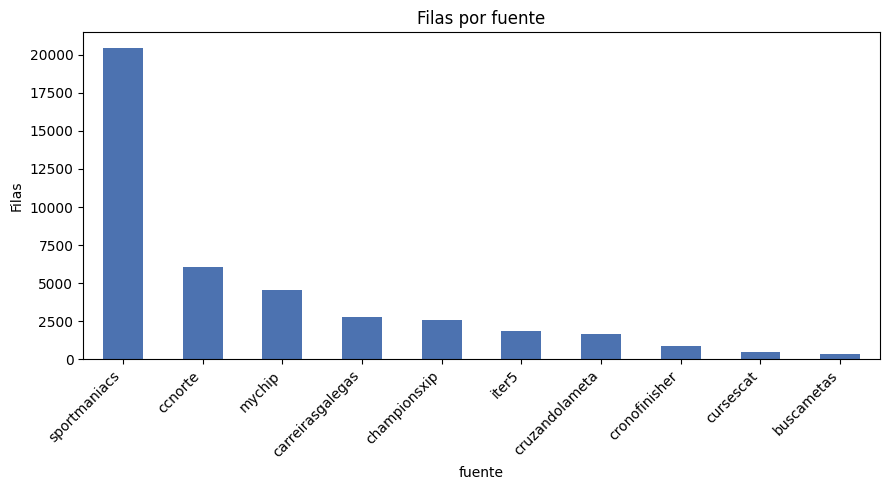

sportmaniacs concentra sola el 49% de las filas. El reparto entre fuentes es muy desigual, así que cualquier estadística global de aquí en adelante está bastante condicionada por esa fuente.


fuente
sportmaniacs        20464
ccnorte              6023
mychip               4545
carreirasgalegas     2797
championsxip         2580
iter5                1834
cruzandolameta       1677
cronofinisher         842
cursescat             469
buscametas            313
Name: count, dtype: int64

In [2]:
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (9, 5)

conteo_fuente = todas["fuente"].value_counts()
conteo_fuente.plot(kind="bar", color="#4C72B0")
plt.title("Filas por fuente")
plt.ylabel("Filas")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

top_fuente = conteo_fuente.index[0]
pct_top = 100 * conteo_fuente.iloc[0] / conteo_fuente.sum()
print(f"{top_fuente} concentra sola el {pct_top:.0f}% de las filas. El reparto entre fuentes es muy desigual, "
      "así que cualquier estadística global de aquí en adelante está bastante condicionada por esa fuente.")
conteo_fuente

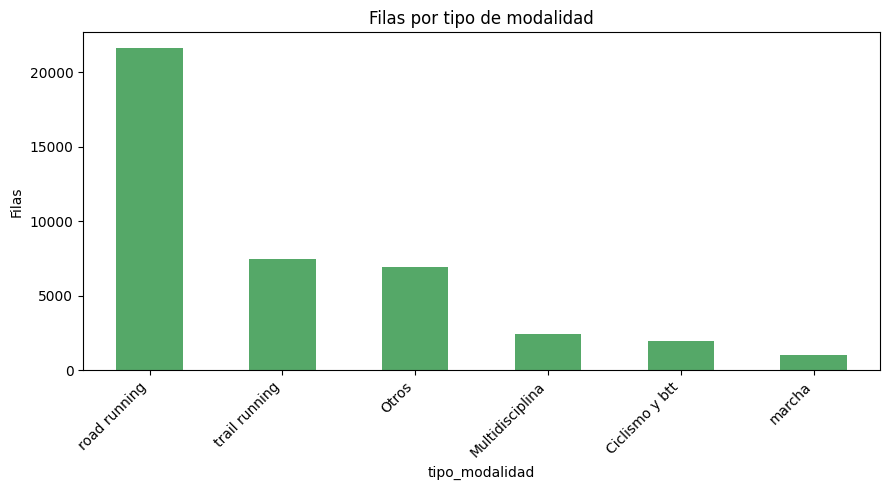

Entre road running y trail running suman el 70% de las filas; el resto de disciplinas (ciclismo, natación, multideporte...) son residuales en comparación.


tipo_modalidad
road running       21606
trail running       7489
Otros               6962
Multidisciplina     2422
Ciclismo y btt      2005
marcha              1060
Name: count, dtype: int64

In [3]:
conteo_tipo = todas["tipo_modalidad"].value_counts()
conteo_tipo.plot(kind="bar", color="#55A868")
plt.title("Filas por tipo de modalidad")
plt.ylabel("Filas")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

pct_top2 = 100 * conteo_tipo.iloc[:2].sum() / conteo_tipo.sum()
print(f"Entre {conteo_tipo.index[0]} y {conteo_tipo.index[1]} suman el {pct_top2:.0f}% de las filas; "
      "el resto de disciplinas (ciclismo, natación, multideporte...) son residuales en comparación.")
conteo_tipo

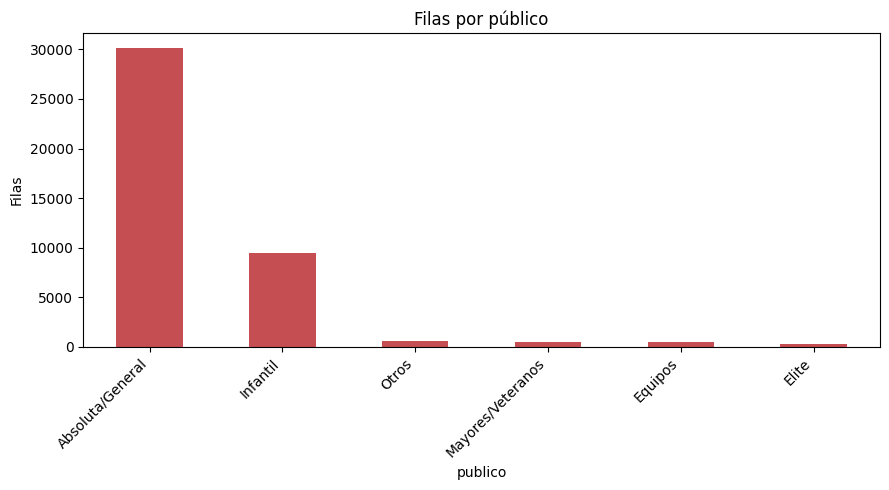

'Absoluta/General' es, con diferencia, la categoría más frecuente (30,154 filas). No es que apenas haya carreras infantiles o de categorías especiales: varias fuentes (cursescat, iter5, buena parte de sportmaniacs) simplemente no desglosan por edad y todo cae en esa categoría genérica.


publico
Absoluta/General     30154
Infantil              9467
Otros                  590
Mayores/Veteranos      518
Equipos                492
Elite                  323
Name: count, dtype: int64

In [4]:
conteo_publico = todas["publico"].value_counts()
conteo_publico.plot(kind="bar", color="#C44E52")
plt.title("Filas por público")
plt.ylabel("Filas")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print(f"'{conteo_publico.index[0]}' es, con diferencia, la categoría más frecuente ({conteo_publico.iloc[0]:,} filas). "
      "No es que apenas haya carreras infantiles o de categorías especiales: varias fuentes (cursescat, iter5, "
      "buena parte de sportmaniacs) simplemente no desglosan por edad y todo cae en esa categoría genérica.")
conteo_publico

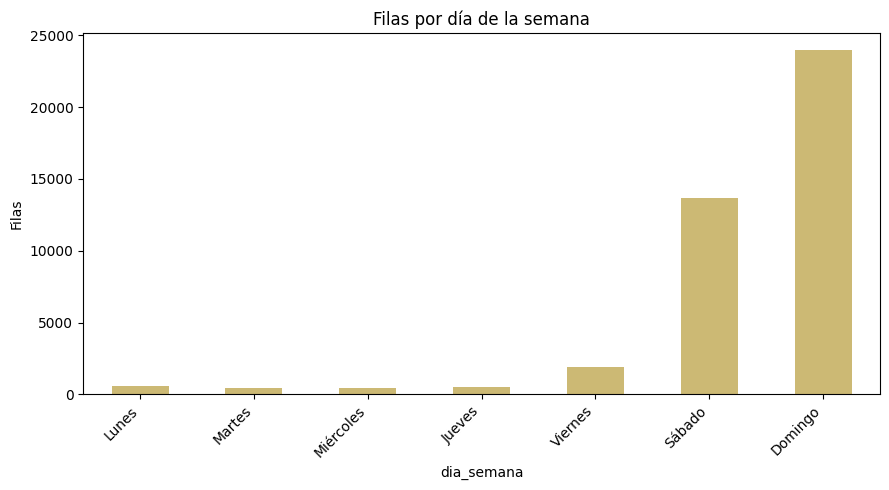

El 91% de las filas caen en sábado o domingo. Las carreras entre semana existen pero son la excepción, no la norma.


dia_semana
Lunes          583
Martes         460
Miércoles      450
Jueves         511
Viernes       1914
Sábado       13645
Domingo      23981
Name: count, dtype: int64

In [5]:
ORDEN_DIAS = ["Lunes", "Martes", "Miércoles", "Jueves", "Viernes", "Sábado", "Domingo"]
por_dia = todas["dia_semana"].value_counts().reindex(ORDEN_DIAS)
por_dia.plot(kind="bar", color="#CCB974")
plt.title("Filas por día de la semana")
plt.ylabel("Filas")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

pct_finde = 100 * por_dia[["Sábado", "Domingo"]].sum() / por_dia.sum()
print(f"El {pct_finde:.0f}% de las filas caen en sábado o domingo. Las carreras entre semana existen "
      "pero son la excepción, no la norma.")
por_dia

Distancia detectada en 20,072 filas de 41,544 (48%); el resto queda en 0 porque la fuente no la da (frecuente en categorías desglosadas solo por edad/género).
count    20072.000000
mean        14.760547
std         21.942394
min          0.001000
25%          5.000000
50%         10.000000
75%         17.000000
max        934.000000
Name: distancia, dtype: float64


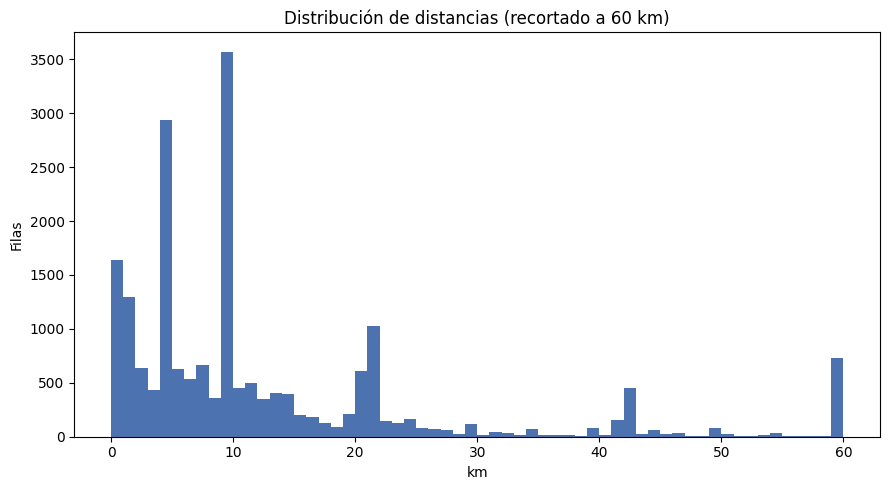

La mediana está en 10 km, con picos claros en las distancias de siempre (5, 10, 21, 42 km). Las distancias de ultra existen pero son cola, no quedan visibles en este recorte a 60 km.


In [6]:
con_distancia = todas.loc[todas["distancia"] != 0, "distancia"]
print(f"Distancia detectada en {len(con_distancia):,} filas de {len(todas):,} "
      f"({100 * len(con_distancia) / len(todas):.0f}%); el resto queda en 0 porque la fuente no la da "
      "(frecuente en categorías desglosadas solo por edad/género).")
print(con_distancia.describe())

con_distancia.clip(upper=60).plot(kind="hist", bins=60, color="#4C72B0")
plt.title("Distribución de distancias (recortado a 60 km)")
plt.xlabel("km")
plt.ylabel("Filas")
plt.tight_layout()
plt.show()

mediana = con_distancia.median()
print(f"La mediana está en {mediana:.0f} km, con picos claros en las distancias de siempre (5, 10, 21, 42 km). "
      "Las distancias de ultra existen pero son cola, no quedan visibles en este recorte a 60 km.")

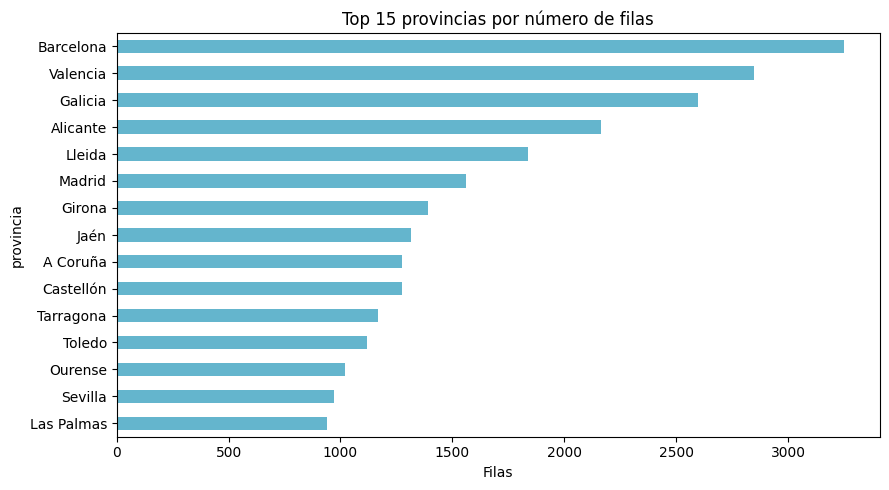

Barcelona encabeza el ranking con 3,248 filas. Esto dice más sobre qué fuentes hemos scrapeado (carreirasgalegas, buscametas y cursescat son monorregionales) que sobre dónde se corre más en España en términos absolutos.


In [7]:
top_provincias = todas["provincia"].value_counts().head(15)
top_provincias.sort_values().plot(kind="barh", color="#64B5CD")
plt.title("Top 15 provincias por número de filas")
plt.xlabel("Filas")
plt.tight_layout()
plt.show()

print(f"{top_provincias.index[0]} encabeza el ranking con {top_provincias.iloc[0]:,} filas. Esto dice más sobre "
      "qué fuentes hemos scrapeado (carreirasgalegas, buscametas y cursescat son monorregionales) que sobre "
      "dónde se corre más en España en términos absolutos.")

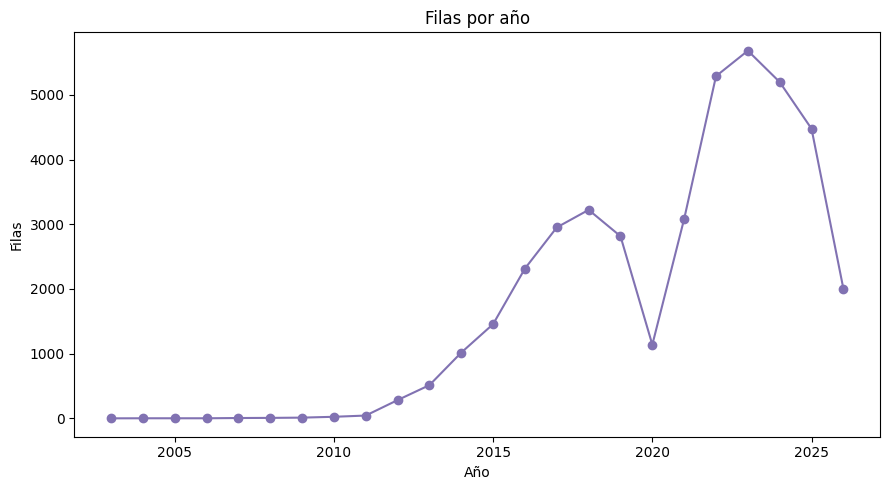

El pico está en 2023, con 5,681 filas. Los años en los extremos (muy antiguos o ya en 2026-2027) tienen pocas filas porque son eventos sueltos o carreras futuras ya programadas, no una caída real de actividad.


In [8]:
por_anyo = todas.groupby("anyo").size()
por_anyo.plot(kind="line", marker="o", color="#8172B2")
plt.title("Filas por año")
plt.ylabel("Filas")
plt.xlabel("Año")
plt.tight_layout()
plt.show()

anyo_max = por_anyo.idxmax()
print(f"El pico está en {anyo_max}, con {por_anyo.max():,} filas. Los años en los extremos (muy antiguos o "
      "ya en 2026-2027) tienen pocas filas porque son eventos sueltos o carreras futuras ya programadas, "
      "no una caída real de actividad.")

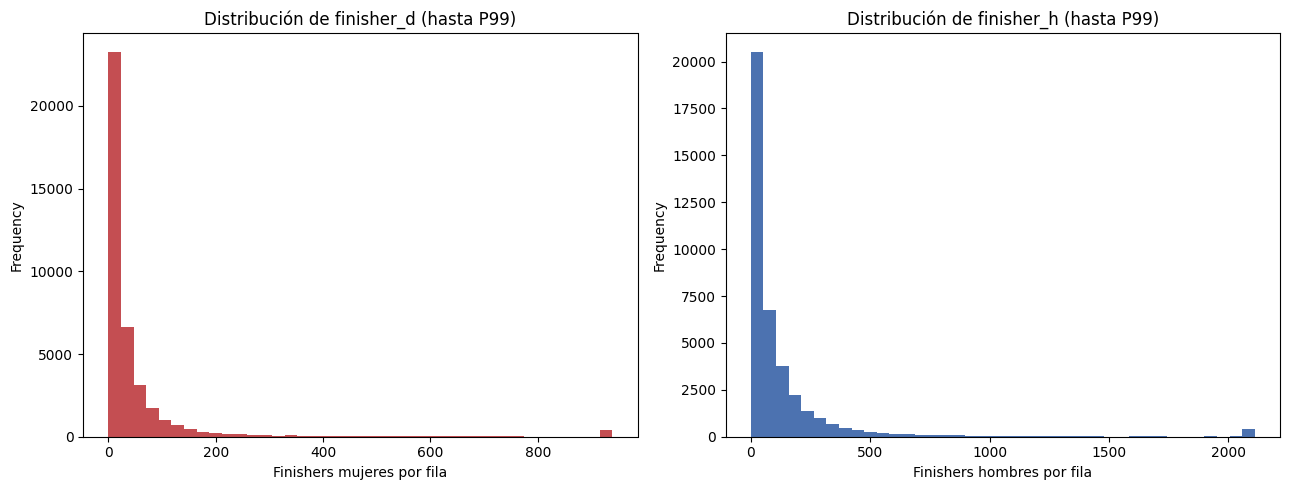

         finisher_d    finisher_h
count  39109.000000  39109.000000
mean      70.459613    147.211614
std      512.458584    469.581315
min        0.000000      0.000000
25%        3.000000     11.000000
50%       16.000000     47.000000
75%       44.000000    131.000000
max    30597.000000  23059.000000

Las dos variables objetivo están muy sesgadas a la derecha: la mediana de finisher_h (47) casi duplica la de finisher_d (16), y ambas tienen una cola larga de carreras con cientos o miles de finishers.


In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

todas["finisher_d"].clip(upper=todas["finisher_d"].quantile(0.99)).plot(kind="hist", bins=40, ax=ax1, color="#C44E52")
ax1.set_title("Distribución de finisher_d (hasta P99)")
ax1.set_xlabel("Finishers mujeres por fila")

todas["finisher_h"].clip(upper=todas["finisher_h"].quantile(0.99)).plot(kind="hist", bins=40, ax=ax2, color="#4C72B0")
ax2.set_title("Distribución de finisher_h (hasta P99)")
ax2.set_xlabel("Finishers hombres por fila")

plt.tight_layout()
plt.show()

print(todas[["finisher_d", "finisher_h"]].describe())
print()
print(f"Las dos variables objetivo están muy sesgadas a la derecha: la mediana de finisher_h "
      f"({todas['finisher_h'].median():.0f}) casi duplica la de finisher_d ({todas['finisher_d'].median():.0f}), "
      "y ambas tienen una cola larga de carreras con cientos o miles de finishers.")

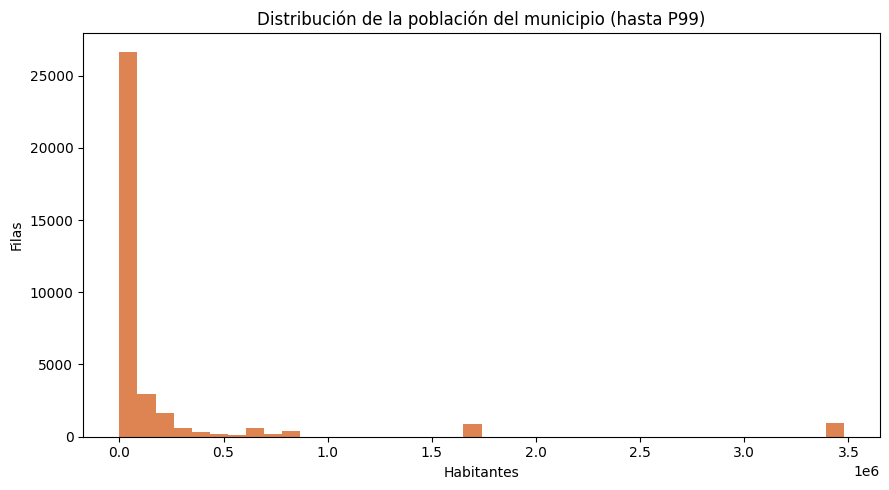

Mediana de 17,062 habitantes: la mayoría de carreras cruzadas ocurren en municipios pequeños o medianos, con una cola de grandes ciudades que estira mucho la media (204,358) por encima de la mediana.


In [10]:
con_poblacion = todas["total_poblacion"].dropna()
con_poblacion.clip(upper=con_poblacion.quantile(0.99)).plot(kind="hist", bins=40, color="#DD8452")
plt.title("Distribución de la población del municipio (hasta P99)")
plt.xlabel("Habitantes")
plt.ylabel("Filas")
plt.tight_layout()
plt.show()

print(f"Mediana de {con_poblacion.median():,.0f} habitantes: la mayoría de carreras cruzadas ocurren en "
      "municipios pequeños o medianos, con una cola de grandes ciudades que estira mucho la media "
      f"({con_poblacion.mean():,.0f}) por encima de la mediana.")

## 2. Correlación entre variables

Para poder meter en una misma matriz de correlación los campos categóricos (`publico`, `tipo_modalidad`, `fuente`, `dia_semana`, `estacion`) hace falta pasarlos a números. En vez de numerarlos sin criterio, usamos algo con sentido: para `dia_semana` y `estacion` el propio calendario ya da un orden natural (Lunes→Domingo, Invierno→Otoño); para `publico`, `tipo_modalidad` y `fuente` no hay un orden evidente, así que codificamos cada categoría según la mediana de `total_finishers` que le corresponde (a más mediana, código más bajo). Así el número refleja "carreras grandes vs. carreras pequeñas" en vez de ser arbitrario.

In [11]:
import numpy as np

DIA_A_NUM = {"Lunes": 1, "Martes": 2, "Miércoles": 3, "Jueves": 4, "Viernes": 5, "Sábado": 6, "Domingo": 7}
ESTACION_A_NUM = {"Invierno": 1, "Primavera": 2, "Verano": 3, "Otoño": 4}

def codificar_por_tamano(columna):
    """Numera las categorías de una columna según la mediana de total_finishers, de mayor a menor."""
    orden = todas.groupby(columna)["total_finishers"].median().sort_values(ascending=False)
    return todas[columna].map({cat: i + 1 for i, cat in enumerate(orden.index)})

num = pd.DataFrame({
    "distancia": todas["distancia"].replace(0, np.nan),
    "anyo": todas["anyo"],
    "es_finde": todas["es_finde"].astype(int),
    "dia_semana_num": todas["dia_semana"].map(DIA_A_NUM),
    "estacion_num": todas["estacion"].map(ESTACION_A_NUM),
    "publico_cod": codificar_por_tamano("publico"),
    "tipo_modalidad_cod": codificar_por_tamano("tipo_modalidad"),
    "fuente_cod": codificar_por_tamano("fuente"),
    "total_poblacion": todas["total_poblacion"],
    "finisher_d": todas["finisher_d"],
    "finisher_h": todas["finisher_h"],
    "total_finishers": todas["total_finishers"],
})

corr = num.corr(numeric_only=True)
corr.round(2)

,distancia,anyo,es_finde,dia_semana_num,estacion_num,publico_cod,tipo_modalidad_cod,fuente_cod,total_poblacion,finisher_d,finisher_h,total_finishers
distancia,1.00,-0.00,0.04,0.01,0.03,-0.18,0.14,-0.17,-0.06,-0.03,0.07,0.02
anyo,-0.00,1.00,-0.01,-0.00,-0.08,0.08,-0.06,0.01,0.00,-0.02,-0.06,-0.05
es_finde,0.04,-0.01,1.00,0.80,0.10,0.01,-0.03,0.05,-0.03,0.01,-0.00,0.00
dia_semana_num,0.01,-0.00,0.80,1.00,0.08,0.01,-0.06,0.04,0.02,0.02,0.01,0.02
estacion_num,0.03,-0.08,0.10,0.08,1.00,-0.04,0.01,0.00,0.01,0.00,-0.05,-0.03
publico_cod,-0.18,0.08,0.01,0.01,-0.04,1.00,0.01,0.29,0.04,-0.06,-0.14,-0.12
tipo_modalidad_cod,0.14,-0.06,-0.03,-0.06,0.01,0.01,1.00,-0.13,-0.06,-0.06,-0.06,-0.07
fuente_cod,-0.17,0.01,0.05,0.04,0.00,0.29,-0.13,1.00,0.07,-0.03,-0.07,-0.06
total_poblacion,-0.06,0.00,-0.03,0.02,0.01,0.04,-0.06,0.07,1.00,0.13,0.14,0.16
finisher_d,-0.03,-0.02,0.01,0.02,0.00,-0.06,-0.06,-0.03,0.13,1.00,0.32,0.83


**`poblacion_h` y `poblacion_d` (población masculina/femenina del municipio) se han excluido a propósito de esta matriz.** Al comprobarlas contra el nomenclátor del INE, `poblacion_h + poblacion_d == total_poblacion` exactamente en las 8.132 filas (no hay ningún error de cruce), y la proporción hombres/mujeres apenas varía entre municipios (media 53%/47%, casi toda entre 50-55%) frente a `total_poblacion`, que va de pueblos de cientos de habitantes a Madrid con más de 3 millones. Con una variable moviéndose en un rango tan grande y la otra casi constante, `poblacion_h` y `poblacion_d` acaban siendo prácticamente reescalados de `total_poblacion` (correlación real ≈0.9999, no un 1.00 por redondeo) — igual de redundante que meter `es_finde` y `dia_semana_num` a la vez, pero más extremo. Para el análisis de correlación y el futuro modelo basta con `total_poblacion`; `poblacion_h`/`poblacion_d` se quedan en `todas` por si hace falta un desglose por sexo más adelante.

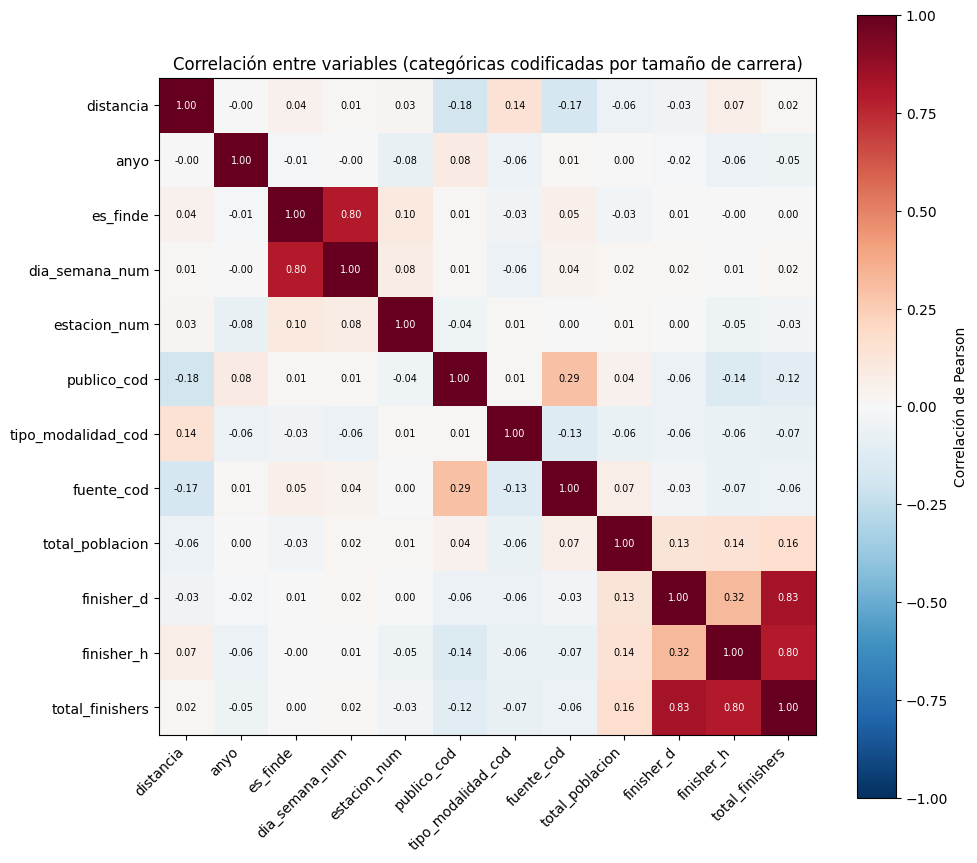

In [12]:
fig, ax = plt.subplots(figsize=(10, 9))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr.columns)))
ax.set_yticklabels(corr.columns)
for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        ax.text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center", fontsize=7,
                 color="white" if abs(corr.values[i, j]) > 0.6 else "black")
ax.set_title("Correlación entre variables (categóricas codificadas por tamaño de carrera)")
fig.colorbar(im, ax=ax, label="Correlación de Pearson")
plt.tight_layout()
plt.show()

In [13]:
pares = corr.mask(np.eye(len(corr), dtype=bool))
pares_target = pares[["finisher_d", "finisher_h"]].drop(index=["finisher_d", "finisher_h", "total_finishers"]).abs()
ranking_target = pares_target.max(axis=1).sort_values(ascending=False)
print("Variables más correlacionadas con los objetivos (valor absoluto):")
print(ranking_target.round(2))
print()
print(f"Ninguna variable por separado pasa de {ranking_target.iloc[0]:.2f}: el tamaño de una carrera no se explica "
      "bien por una sola columna, hace falta combinarlas (que es justo lo que hará el árbol). Las que más pesan "
      "son la población del municipio y publico_cod; distancia, día de la semana y estación aportan poco por sí "
      f"solos. Por otro lado, es_finde y dia_semana_num van casi calcadas entre sí "
      f"({corr.loc['es_finde', 'dia_semana_num']:.2f} de correlación), lógico porque una se deriva de la otra, "
      "así que no tiene mucho sentido meter las dos en el mismo modelo.")

Variables más correlacionadas con los objetivos (valor absoluto):
total_poblacion       0.14
publico_cod           0.14
distancia             0.07
fuente_cod            0.07
tipo_modalidad_cod    0.06
anyo                  0.06
estacion_num          0.05
dia_semana_num        0.02
es_finde              0.01
dtype: float64

Ninguna variable por separado pasa de 0.14: el tamaño de una carrera no se explica bien por una sola columna, hace falta combinarlas (que es justo lo que hará el árbol). Las que más pesan son la población del municipio y publico_cod; distancia, día de la semana y estación aportan poco por sí solos. Por otro lado, es_finde y dia_semana_num van casi calcadas entre sí (0.80 de correlación), lógico porque una se deriva de la otra, así que no tiene mucho sentido meter las dos en el mismo modelo.


## 3. Análisis bivariable frente a los objetivos

Aquí cruzamos cada variable con `finisher_d` y `finisher_h` a la vez, en vez de mirar solo el total, para ver si además del tamaño de la carrera cambia el reparto entre hombres y mujeres.

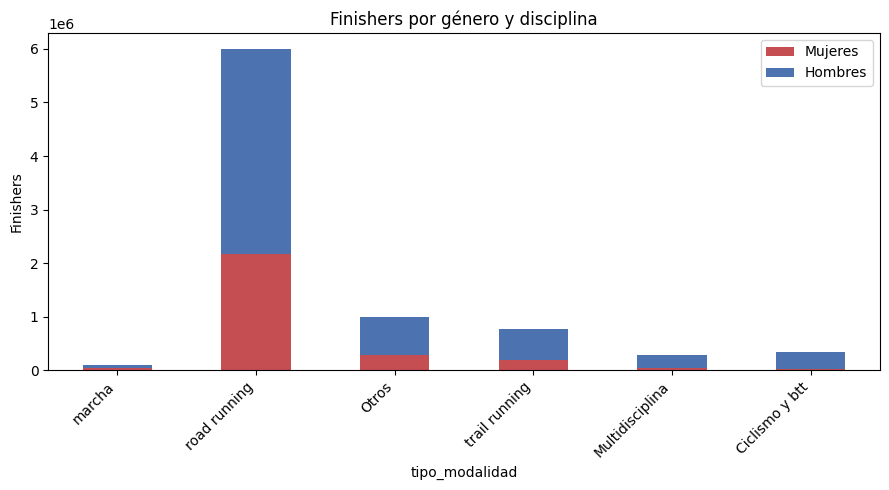

marcha es la disciplina más paritaria (38% mujeres) y Ciclismo y btt la menos (6% mujeres). En ninguna disciplina se llega al 50%, la participación femenina siempre queda por debajo de la masculina.


,finisher_d,finisher_h,pct_mujeres
tipo_modalidad,,,
marcha,41074.0,67609.0,37.792479
road running,2169737.0,3829068.0,36.169487
Otros,280898.0,718935.0,28.094492
trail running,203519.0,572063.0,26.240810
Multidisciplina,40416.0,238282.0,14.501719
Ciclismo y btt,19961.0,331342.0,5.681990


In [14]:
por_tipo = todas.groupby("tipo_modalidad")[["finisher_d", "finisher_h"]].sum()
por_tipo["pct_mujeres"] = 100 * por_tipo["finisher_d"] / (por_tipo["finisher_d"] + por_tipo["finisher_h"])
por_tipo = por_tipo.sort_values("pct_mujeres", ascending=False)

por_tipo[["finisher_d", "finisher_h"]].plot(kind="bar", stacked=True, color=["#C44E52", "#4C72B0"])
plt.title("Finishers por género y disciplina")
plt.ylabel("Finishers")
plt.xticks(rotation=45, ha="right")
plt.legend(["Mujeres", "Hombres"])
plt.tight_layout()
plt.show()

print(f"{por_tipo['pct_mujeres'].idxmax()} es la disciplina más paritaria ({por_tipo['pct_mujeres'].max():.0f}% mujeres) "
      f"y {por_tipo['pct_mujeres'].idxmin()} la menos ({por_tipo['pct_mujeres'].min():.0f}% mujeres). "
      "En ninguna disciplina se llega al 50%, la participación femenina siempre queda por debajo de la masculina.")
por_tipo

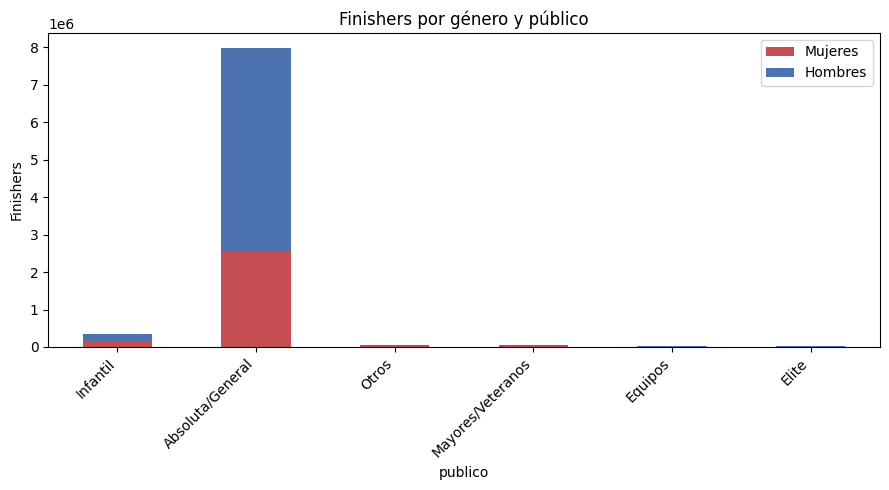

El reparto por género cambia bastante según el público: Infantil tiene el 43% de mujeres, mientras que en Elite apenas llega al 21%. No es solo que unas categorías tengan carreras más grandes que otras, también varía quién participa en ellas.


,finisher_d,finisher_h,pct_mujeres
publico,,,
Infantil,151858.0,201461.0,42.980423
Absoluta/General,2553435.0,5435169.0,31.963469
Otros,19224.0,41932.0,31.434365
Mayores/Veteranos,18139.0,41131.0,30.604016
Equipos,10317.0,27811.0,27.058854
Elite,2632.0,9795.0,21.179689


In [15]:
por_publico = todas.groupby("publico")[["finisher_d", "finisher_h"]].sum()
por_publico["pct_mujeres"] = 100 * por_publico["finisher_d"] / (por_publico["finisher_d"] + por_publico["finisher_h"])
por_publico = por_publico.sort_values("pct_mujeres", ascending=False)

por_publico[["finisher_d", "finisher_h"]].plot(kind="bar", stacked=True, color=["#C44E52", "#4C72B0"])
plt.title("Finishers por género y público")
plt.ylabel("Finishers")
plt.xticks(rotation=45, ha="right")
plt.legend(["Mujeres", "Hombres"])
plt.tight_layout()
plt.show()

print(f"El reparto por género cambia bastante según el público: {por_publico['pct_mujeres'].idxmax()} tiene el "
      f"{por_publico['pct_mujeres'].max():.0f}% de mujeres, mientras que en {por_publico['pct_mujeres'].idxmin()} "
      f"apenas llega al {por_publico['pct_mujeres'].min():.0f}%. No es solo que unas categorías tengan carreras "
      "más grandes que otras, también varía quién participa en ellas.")
por_publico

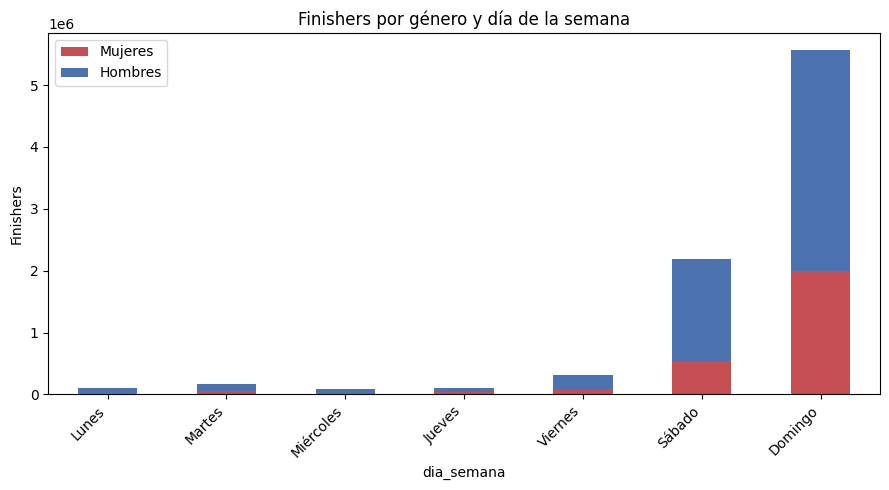

            finisher_d  finisher_h  pct_mujeres
dia_semana                                     
Lunes          26325.0     74766.0    26.040894
Martes         51433.0    109361.0    31.986890
Miércoles      28231.0     64329.0    30.500216
Jueves         35396.0     68572.0    34.045091
Viernes        74520.0    232073.0    24.305839
Sábado        541867.0   1638800.0    24.848682
Domingo      1997833.0   3569398.0    35.885578

El % de mujeres se mueve entre 24% y 36% según el día, sin una tendencia clara fin de semana vs. entre semana; el volumen total sí que es muchísimo mayor en sábado y domingo, como ya se vio en el univariable.


In [16]:
ORDEN_DIAS = ["Lunes", "Martes", "Miércoles", "Jueves", "Viernes", "Sábado", "Domingo"]
por_dia_gen = todas.groupby("dia_semana")[["finisher_d", "finisher_h"]].sum().reindex(ORDEN_DIAS)
por_dia_gen["pct_mujeres"] = 100 * por_dia_gen["finisher_d"] / (por_dia_gen["finisher_d"] + por_dia_gen["finisher_h"])

fig, ax1 = plt.subplots(figsize=(9, 5))
por_dia_gen[["finisher_d", "finisher_h"]].plot(kind="bar", stacked=True, ax=ax1, color=["#C44E52", "#4C72B0"])
ax1.set_title("Finishers por género y día de la semana")
ax1.set_ylabel("Finishers")
ax1.legend(["Mujeres", "Hombres"])
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print(por_dia_gen)
print()
print(f"El % de mujeres se mueve entre {por_dia_gen['pct_mujeres'].min():.0f}% y {por_dia_gen['pct_mujeres'].max():.0f}% "
      "según el día, sin una tendencia clara fin de semana vs. entre semana; el volumen total sí que es "
      "muchísimo mayor en sábado y domingo, como ya se vio en el univariable.")

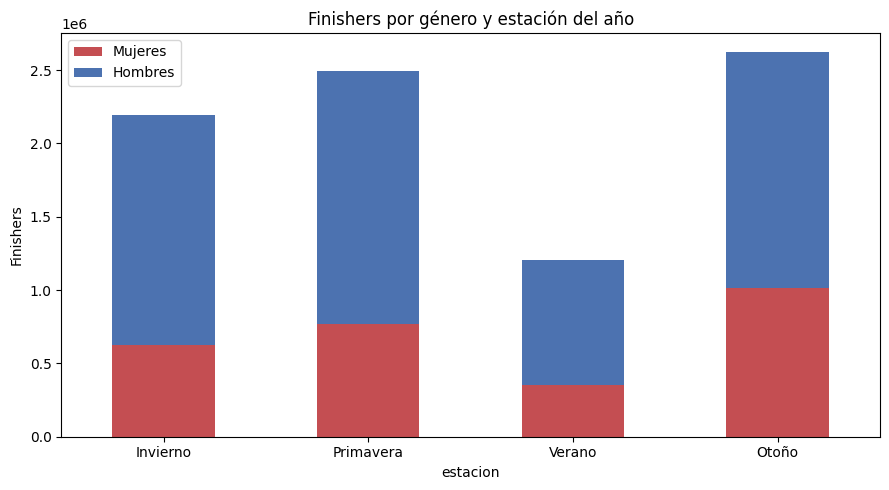

           finisher_d  finisher_h  pct_mujeres
estacion                                      
Invierno     626911.0   1563908.0    28.615372
Primavera    765553.0   1730171.0    30.674586
Verano       352547.0    851318.0    29.284596
Otoño       1010594.0   1611902.0    38.535578

Otoño concentra el mayor volumen de finishers, coherente con el calendario de carreras que ya vimos en el univariable (menos carreras no significa necesariamente menos participación total, si las que hay son más grandes).


In [17]:
ORDEN_ESTACIONES = ["Invierno", "Primavera", "Verano", "Otoño"]
por_estacion_gen = todas.groupby("estacion")[["finisher_d", "finisher_h"]].sum().reindex(ORDEN_ESTACIONES)
por_estacion_gen["pct_mujeres"] = 100 * por_estacion_gen["finisher_d"] / (por_estacion_gen["finisher_d"] + por_estacion_gen["finisher_h"])

por_estacion_gen[["finisher_d", "finisher_h"]].plot(kind="bar", stacked=True, color=["#C44E52", "#4C72B0"])
plt.title("Finishers por género y estación del año")
plt.ylabel("Finishers")
plt.xticks(rotation=0)
plt.legend(["Mujeres", "Hombres"])
plt.tight_layout()
plt.show()

print(por_estacion_gen)
print()
print(f"{por_estacion_gen['finisher_d'].add(por_estacion_gen['finisher_h']).idxmax()} concentra el mayor volumen "
      "de finishers, coherente con el calendario de carreras que ya vimos en el univariable (menos carreras "
      "no significa necesariamente menos participación total, si las que hay son más grandes).")

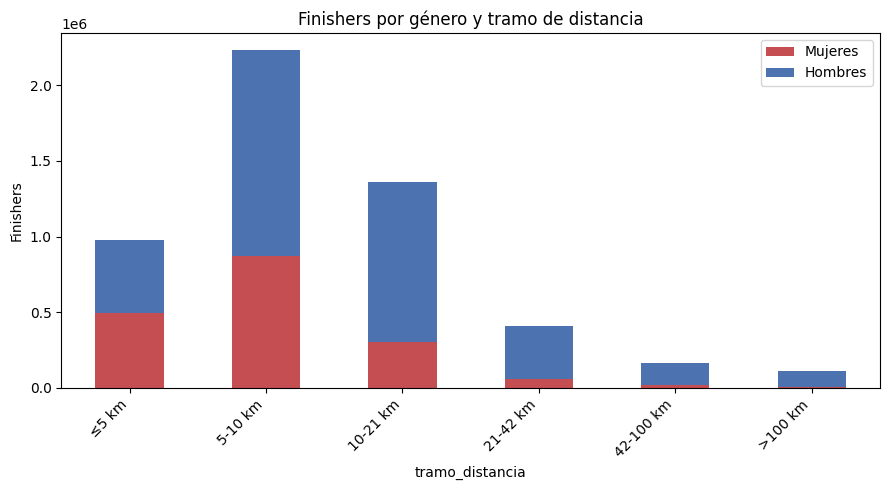

                 finisher_d  finisher_h  pct_mujeres
tramo_distancia                                     
≤5 km              492402.0    485715.0    50.341830
5-10 km            871992.0   1362867.0    39.017764
10-21 km           302877.0   1056049.0    22.287969
21-42 km            61595.0    347643.0    15.051144
42-100 km           18306.0    146174.0    11.129621
>100 km              6837.0    104914.0     6.118066

El % de mujeres cae de forma bastante consistente a medida que crece la distancia: 50% en el tramo más corto frente a 6% en el más largo. En las distancias de ultra la brecha de género es mucho más marcada que en las carreras populares cortas.


In [18]:
con_distancia_gen = todas[todas["distancia"] != 0].copy()
bins = [0, 5, 10, 21.5, 42.5, 100, con_distancia_gen["distancia"].max() + 1]
etiquetas = ["≤5 km", "5-10 km", "10-21 km", "21-42 km", "42-100 km", ">100 km"]
con_distancia_gen["tramo_distancia"] = pd.cut(con_distancia_gen["distancia"], bins=bins, labels=etiquetas)

por_distancia_gen = con_distancia_gen.groupby("tramo_distancia", observed=True)[["finisher_d", "finisher_h"]].sum()
por_distancia_gen["pct_mujeres"] = 100 * por_distancia_gen["finisher_d"] / (por_distancia_gen["finisher_d"] + por_distancia_gen["finisher_h"])

por_distancia_gen[["finisher_d", "finisher_h"]].plot(kind="bar", stacked=True, color=["#C44E52", "#4C72B0"])
plt.title("Finishers por género y tramo de distancia")
plt.ylabel("Finishers")
plt.xticks(rotation=45, ha="right")
plt.legend(["Mujeres", "Hombres"])
plt.tight_layout()
plt.show()

print(por_distancia_gen)
print()
print(f"El % de mujeres cae de forma bastante consistente a medida que crece la distancia: "
      f"{por_distancia_gen['pct_mujeres'].iloc[0]:.0f}% en el tramo más corto frente a "
      f"{por_distancia_gen['pct_mujeres'].iloc[-1]:.0f}% en el más largo. En las distancias de ultra "
      "la brecha de género es mucho más marcada que en las carreras populares cortas.")

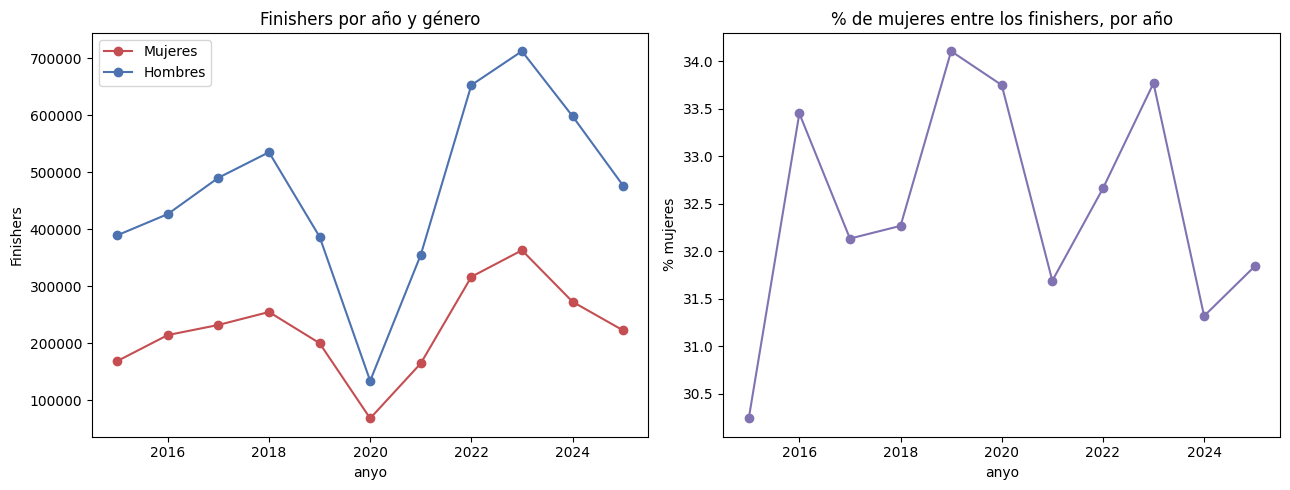

Entre 2015 y 2025 los finishers hombres se multiplican por 1.2 y los finishers mujeres por 1.3: la participación femenina crece algo más rápido en términos relativos, aunque sigue partiendo de una base mucho más baja, así que el % de mujeres solo sube de 30% a 32%.


In [19]:
por_anyo_gen = (
    todas[(todas["anyo"] >= 2015) & (todas["anyo"] <= 2025)]
    .groupby("anyo")[["finisher_d", "finisher_h"]].sum()
)
por_anyo_gen["pct_mujeres"] = 100 * por_anyo_gen["finisher_d"] / (por_anyo_gen["finisher_d"] + por_anyo_gen["finisher_h"])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
por_anyo_gen[["finisher_d", "finisher_h"]].plot(marker="o", ax=ax1, color=["#C44E52", "#4C72B0"])
ax1.set_title("Finishers por año y género")
ax1.set_ylabel("Finishers")
ax1.legend(["Mujeres", "Hombres"])

por_anyo_gen["pct_mujeres"].plot(marker="o", ax=ax2, color="#8172B2")
ax2.set_title("% de mujeres entre los finishers, por año")
ax2.set_ylabel("% mujeres")

plt.tight_layout()
plt.show()

crecim_d = por_anyo_gen["finisher_d"].iloc[-1] / por_anyo_gen["finisher_d"].iloc[0]
crecim_h = por_anyo_gen["finisher_h"].iloc[-1] / por_anyo_gen["finisher_h"].iloc[0]
print(f"Entre {por_anyo_gen.index[0]} y {por_anyo_gen.index[-1]} los finishers hombres se multiplican por "
      f"{crecim_h:.1f} y los finishers mujeres por {crecim_d:.1f}: la participación femenina crece algo más "
      "rápido en términos relativos, aunque sigue partiendo de una base mucho más baja, así que el % de "
      f"mujeres solo sube de {por_anyo_gen['pct_mujeres'].iloc[0]:.0f}% a {por_anyo_gen['pct_mujeres'].iloc[-1]:.0f}%.")

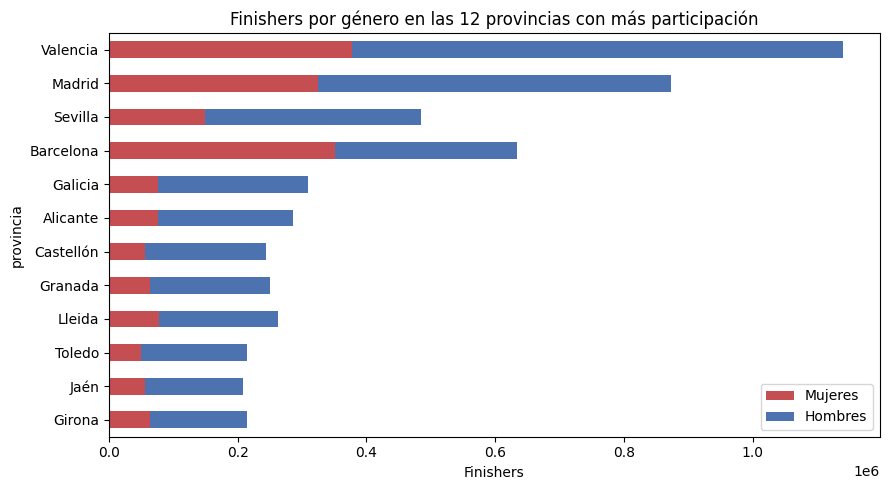

           finisher_d  finisher_h  pct_mujeres
provincia                                     
Valencia     377443.0    763459.0         33.1
Madrid       324708.0    549208.0         37.2
Barcelona    351492.0    281796.0         55.5
Sevilla      150061.0    334981.0         30.9
Galicia       75849.0    232725.0         24.6
Alicante      76491.0    209949.0         26.7
Lleida        77088.0    186146.0         29.3
Granada       63187.0    187405.0         25.2
Castellón     56390.0    188372.0         23.0
Girona        63442.0    150997.0         29.6
Toledo        50322.0    163882.0         23.5
Jaén          56140.0    152288.0         26.9

Dentro del top de provincias por volumen, el % de mujeres va de 23% a 56%: tener mucha participación total no implica tener una participación más equilibrada por género.


In [20]:
top_provincias_gen = (
    todas.groupby("provincia")[["finisher_d", "finisher_h"]].sum()
    .assign(total=lambda d: d["finisher_d"] + d["finisher_h"])
    .sort_values("total", ascending=False)
    .head(12)
)
top_provincias_gen["pct_mujeres"] = 100 * top_provincias_gen["finisher_d"] / top_provincias_gen["total"]

top_provincias_gen[["finisher_d", "finisher_h"]].sort_values("finisher_h").plot(
    kind="barh", stacked=True, color=["#C44E52", "#4C72B0"]
)
plt.title("Finishers por género en las 12 provincias con más participación")
plt.xlabel("Finishers")
plt.legend(["Mujeres", "Hombres"])
plt.tight_layout()
plt.show()

print(top_provincias_gen[["finisher_d", "finisher_h", "pct_mujeres"]].round(1))
print()
print(f"Dentro del top de provincias por volumen, el % de mujeres va de {top_provincias_gen['pct_mujeres'].min():.0f}% "
      f"a {top_provincias_gen['pct_mujeres'].max():.0f}%: tener mucha participación total no implica tener "
      "una participación más equilibrada por género.")

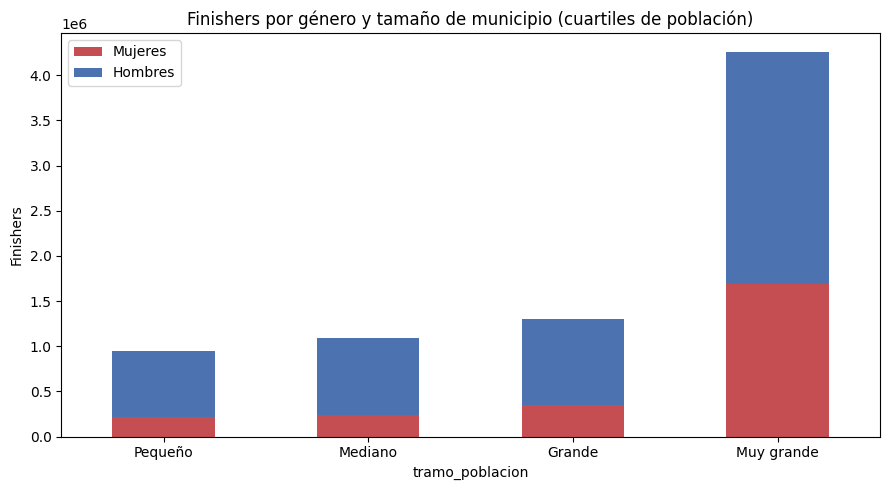

                 finisher_d  finisher_h  pct_mujeres
tramo_poblacion                                     
Pequeño            214124.0    731568.0    22.642044
Mediano            244250.0    848242.0    22.357143
Grande             347942.0    954418.0    26.716269
Muy grande        1689628.0   2566074.0    39.702686

El % de mujeres pasa de 23% en los municipios más pequeños a 40% en los más grandes: las ciudades grandes tienen una participación algo más equilibrada que los pueblos, aunque la diferencia no es enorme. Recordar que esto solo cubre el ~83% de filas donde el cruce con el INE ha funcionado.


In [21]:
con_poblacion_gen = todas[todas["total_poblacion"].notna()].copy()
con_poblacion_gen["tramo_poblacion"] = pd.qcut(
    con_poblacion_gen["total_poblacion"], q=4, labels=["Pequeño", "Mediano", "Grande", "Muy grande"]
)

por_poblacion_gen = con_poblacion_gen.groupby("tramo_poblacion", observed=True)[["finisher_d", "finisher_h"]].sum()
por_poblacion_gen["pct_mujeres"] = 100 * por_poblacion_gen["finisher_d"] / (por_poblacion_gen["finisher_d"] + por_poblacion_gen["finisher_h"])

por_poblacion_gen[["finisher_d", "finisher_h"]].plot(kind="bar", stacked=True, color=["#C44E52", "#4C72B0"])
plt.title("Finishers por género y tamaño de municipio (cuartiles de población)")
plt.ylabel("Finishers")
plt.xticks(rotation=0)
plt.legend(["Mujeres", "Hombres"])
plt.tight_layout()
plt.show()

print(por_poblacion_gen)
print()
print(f"El % de mujeres pasa de {por_poblacion_gen['pct_mujeres'].iloc[0]:.0f}% en los municipios más pequeños a "
      f"{por_poblacion_gen['pct_mujeres'].iloc[-1]:.0f}% en los más grandes: las ciudades grandes tienen una "
      "participación algo más equilibrada que los pueblos, aunque la diferencia no es enorme. Recordar que "
      "esto solo cubre el ~83% de filas donde el cruce con el INE ha funcionado.")

## 4. Histórico de la misma carrera, año a año

Todo lo anterior mira cada fila como si fuera independiente, pero muchas carreras se repiten año tras año con el mismo formato — y el tamaño de la edición anterior es, en principio, el mejor indicio del tamaño de la siguiente. Para comprobarlo hace falta identificar cuándo dos filas de años distintos son "la misma carrera": quitamos del nombre el ordinal de la edición (I, II, 1ª, XXIII...) y el año suelto, y agrupamos por ese nombre base dentro de cada fuente.

In [22]:
def _normalizar_base(nombre):
    if pd.isna(nombre):
        return None
    t = unicodedata.normalize("NFKD", str(nombre)).encode("ascii", "ignore").decode("ascii").upper()
    t = re.sub(r"[^A-Z0-9]+", " ", t)
    t = re.sub(r"^\s*(?:[IVXLC]{1,6}|\d{1,3}(?:A|O|ER|ERA)?)\b\s*", "", t)  # ordinal inicial
    t = re.sub(r"\b(19|20)\d{2}\b", "", t)  # año suelto
    return re.sub(r"\s{2,}", " ", t).strip()

todas["nombre_base"] = todas["nombre_carrera"].apply(_normalizar_base)

ediciones_por_carrera = todas.groupby(["fuente", "nombre_base"])["anyo"].nunique()
print(f"Carreras (fuente + nombre base) con datos en 2 años o más: "
      f"{(ediciones_por_carrera > 1).sum()} de {len(ediciones_por_carrera)} "
      f"({100*(ediciones_por_carrera > 1).mean():.0f}%)")

Carreras (fuente + nombre base) con datos en 2 años o más: 3249 de 10830 (30%)


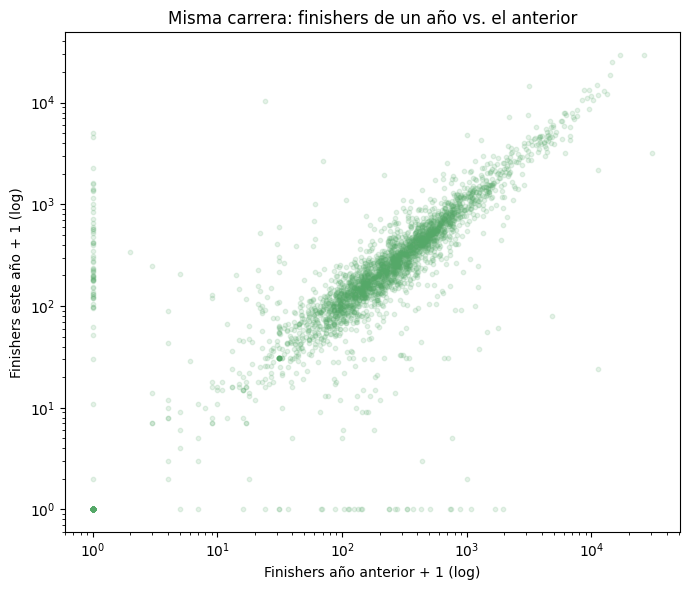

Pares de ediciones consecutivas disponibles: 5956
Correlación finishers(año) vs. finishers(año-1), misma carrera: 0.90

Es, con diferencia, la señal más fuerte de todo el análisis (todo lo demás en el heatmap se quedaba por debajo de 0.16): saber cuánta gente corrió la edición anterior de una carrera predice muchísimo mejor la siguiente que cualquier combinación de tipo_modalidad/publico/distancia/población. Para el árbol de finishers, el histórico propio de cada carrera (cuando existe) debería ser el predictor principal, y el resto de variables quedarían para las carreras nuevas sin historial.


In [23]:
# Para cada carrera, comparamos el total de finishers de un año con el del
# año inmediatamente anterior (solo años consecutivos, para no mezclar
# ediciones con un hueco de por medio).
por_anyo = todas.groupby(["fuente", "nombre_base", "anyo"])["total_finishers"].sum().reset_index()
por_anyo = por_anyo.sort_values(["fuente", "nombre_base", "anyo"])
por_anyo["anyo_anterior"] = por_anyo.groupby(["fuente", "nombre_base"])["anyo"].shift(1)
por_anyo["finishers_anyo_anterior"] = por_anyo.groupby(["fuente", "nombre_base"])["total_finishers"].shift(1)

consecutivos = por_anyo[por_anyo["anyo"] - por_anyo["anyo_anterior"] == 1].dropna(subset=["finishers_anyo_anterior"])
corr_historico = consecutivos["total_finishers"].corr(consecutivos["finishers_anyo_anterior"])

muestra = consecutivos.sample(min(3000, len(consecutivos)), random_state=0)
plt.figure(figsize=(7, 6))
plt.scatter(muestra["finishers_anyo_anterior"] + 1, muestra["total_finishers"] + 1, alpha=0.15, s=10, color="#55A868")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Finishers año anterior + 1 (log)")
plt.ylabel("Finishers este año + 1 (log)")
plt.title("Misma carrera: finishers de un año vs. el anterior")
plt.tight_layout()
plt.show()

print(f"Pares de ediciones consecutivas disponibles: {len(consecutivos)}")
print(f"Correlación finishers(año) vs. finishers(año-1), misma carrera: {corr_historico:.2f}")
print()
print("Es, con diferencia, la señal más fuerte de todo el análisis (todo lo demás en el heatmap se "
      "quedaba por debajo de 0.16): saber cuánta gente corrió la edición anterior de una carrera predice "
      "muchísimo mejor la siguiente que cualquier combinación de tipo_modalidad/publico/distancia/población. "
      "Para el árbol de finishers, el histórico propio de cada carrera (cuando existe) debería ser el "
      "predictor principal, y el resto de variables quedarían para las carreras nuevas sin historial.")

## Notas finales

- Las distancias por encima de 100 km (272 filas) casi todas son reales: marchas cicloturistas/gran fondo (Mallorca 312, Marcha Ciclodeportiva Guad al Xenil...) y ultra-trails ("100 Millas Sierras del Bandolero") de verdad llegan a esas distancias. Solo un puñado son casos raros de verdad: un par de "retos" acumulados a lo largo de semanas ("GR7 por la Epilepsia", 934 km, no es una carrera de un día) y "EPIC RACE PONTEVEDRA" con 300/200 km que no cuadra con lo que suele ser esa marca (carreras de obstáculos cortas) — probablemente un fallo de extracción puntual, sin investigar más por ahora.
- `comarca` tiene cobertura muy desigual entre fuentes (buena en Catalunya/Galicia, floja en el resto), mejor no usarla a nivel global sin filtrar antes por región.
- `distancia == 0` es un centinela de "no detectado", no una distancia real; para cualquier cálculo con distancia hay que filtrarlo antes.
- `cruzandolameta` todavía no incluye los eventos en PDF, quedan pendientes de una futura ampliación del scraper.
- El cruce con el INE cubre alrededor del 83% de las filas tras el fallback por comunidad autónoma (ver sección 2); el resto son sobre todo municipios con un nombre distinto al oficial del nomenclátor (exónimos históricos, especialmente en mychip).
- Esta tabla viene de `DF_TODAS_UNION.csv` (generado por `Limpieza_union.ipynb`), ya con las columnas derivadas calculadas — no hace falta recalcular nada al recargarla. `DF_TODAS.csv` sigue existiendo solo con las 12 columnas comunes, para quien parta de cero.
- `es_carrera_popular` (carreras cuyo nombre contiene "popular") también viene ya calculado en `DF_TODAS_UNION.csv` — pensado para las carreras de `road running`/`Absoluta-General`, que deberían ser más fáciles de predecir al ser un tipo de evento más homogéneo.
- Para preparar los datos de cara al árbol de finishers, ver `Limpieza_outliers.ipynb`: convierte el centinela de `distancia` en `NaN` y guarda `DF_TODAS_SIN_OUTLIERS.csv`.
- De cara al modelo: ninguna variable por separado correlaciona fuerte con `finisher_d`/`finisher_h` (todas por debajo de 0.15), así que el árbol necesitará combinarlas; `publico` y la población del municipio son las que más pesan de forma aislada, y `distancia` apenas aporta nada por sí sola. `es_finde` y `dia_semana` van casi calcadas entre sí, así que no hace falta meter las dos en el modelo. Hay una tendencia temporal a lo largo de los años que probablemente merece entrar como predictor si el modelo se va a usar para carreras futuras.
- **Para el split train/test del futuro modelo: nada de partir filas al azar.** La misma carrera en años consecutivos está correlacionada al 0.90 en finishers (ver sección 4), así que un split aleatorio dejaría la edición 2022 de una carrera en train y la 2023 en test — el modelo parecería mucho mejor de lo que realmente es porque estaría casi copiando la respuesta. Hay que partir por carrera (`nombre_base`) o por corte temporal (años), nunca por fila individual.